In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


In [2]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")

In [3]:
df_submit=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

In [4]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [6]:
df.sample(4)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
431569,431569,COU,HARD,Mexico City Grand Prix,2024,0,54,2,28.0,10,80.739,-10.988,-88.477,0.701299,-1.0,1.0
231805,231805,D084,HARD,Monaco Grand Prix,2024,0,28,2,27.0,14,83.859,-13.865,-36.154,0.368421,-1.0,1.0
258675,258675,KUB,HARD,Monaco Grand Prix,2024,1,1,1,1.0,9,88.804,-22.845,-38.516,0.012987,5.0,0.0
346269,346269,D042,HARD,Italian Grand Prix,2024,0,48,3,11.0,3,82.841,-0.734,-25.816,0.615385,-2.0,0.0


Univariate analysis on every column

Driver

In [7]:
df['Driver'].nunique()

887

In [8]:
top_drivers=df['Driver'].value_counts().head(30)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

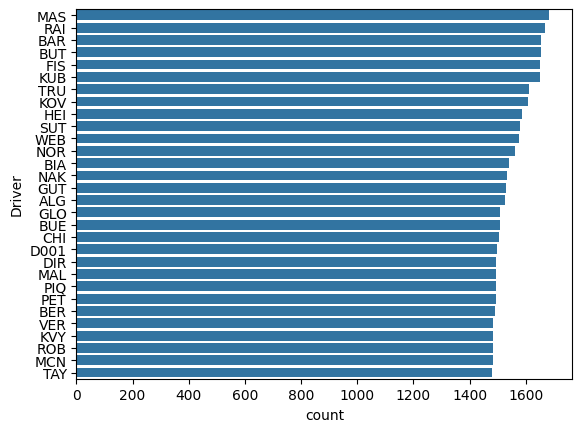

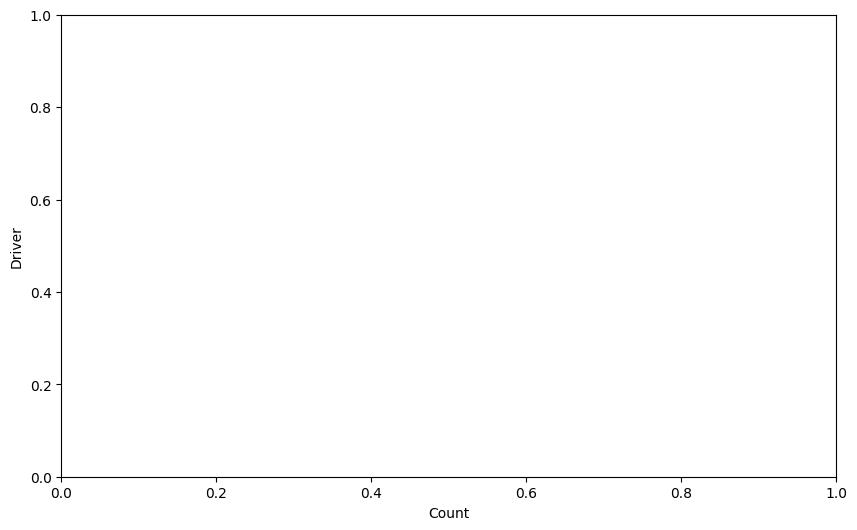

In [10]:
sns.countplot(y=df['Driver'],order=top_drivers.index)
plt.figure(figsize=(10,6))
plt.xlabel('Count')
plt.ylabel('Driver')
plt.show

Compound

In [11]:
df['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET'], dtype=object)

Use OHE in Compound

<Axes: ylabel='count'>

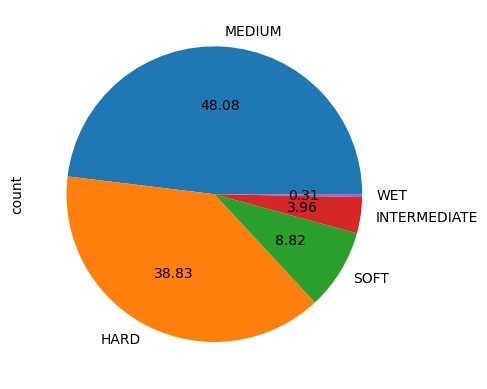

In [12]:
df['Compound'].value_counts().plot(kind='pie',autopct='%.2f',radius=1)

Race

In [13]:
df['Race'].nunique()

26

OHE on Race

<function matplotlib.pyplot.show(close=None, block=None)>

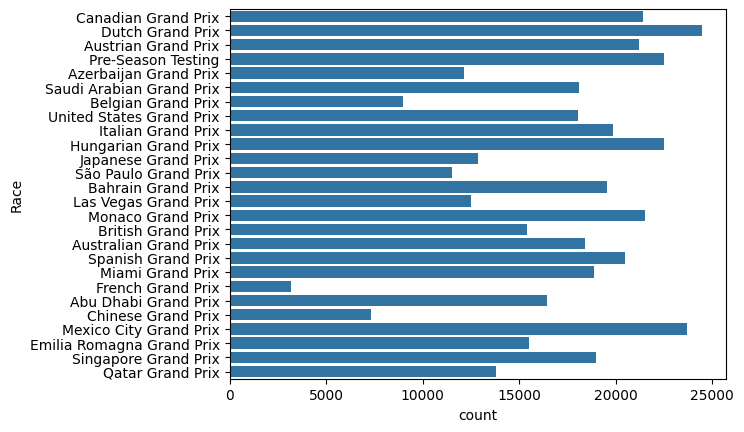

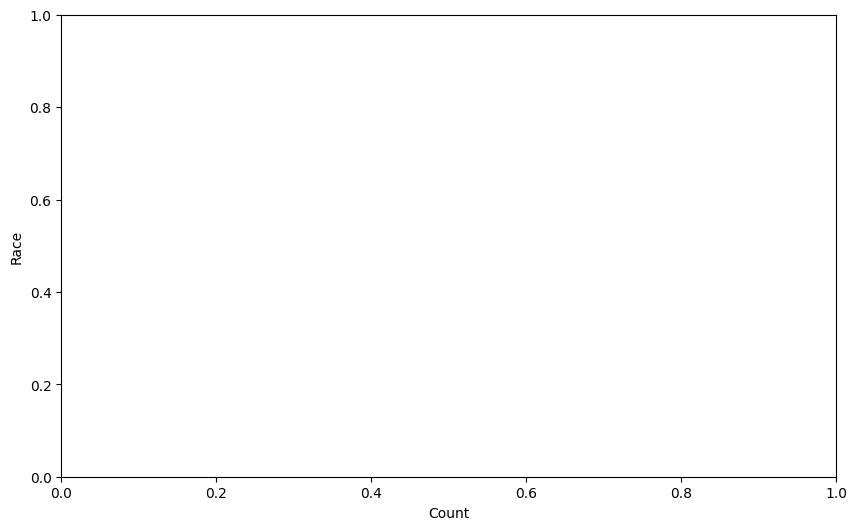

In [14]:
sns.countplot(y=df['Race'])
plt.figure(figsize=(10,6))
plt.xlabel('Count')
plt.ylabel('Race')
plt.show

Year

In [15]:
df['Year'].unique

<bound method Series.unique of 0         2022
1         2025
2         2022
3         2023
4         2022
          ... 
439135    2023
439136    2023
439137    2023
439138    2023
439139    2023
Name: Year, Length: 439140, dtype: int64>

<Axes: ylabel='Year'>

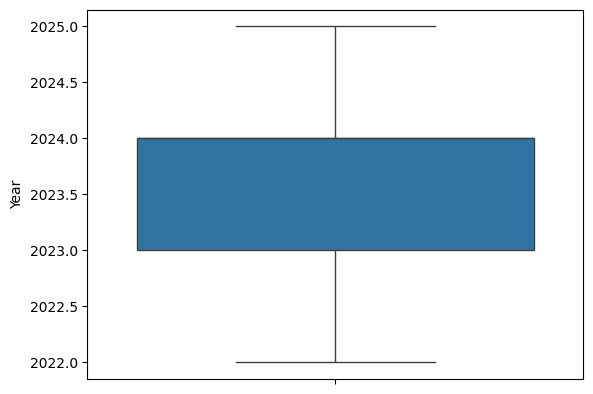

In [16]:
sns.boxplot(df['Year'])

No outliers in Year

In [17]:
df['PitStop'].nunique()

2

<Axes: ylabel='count'>

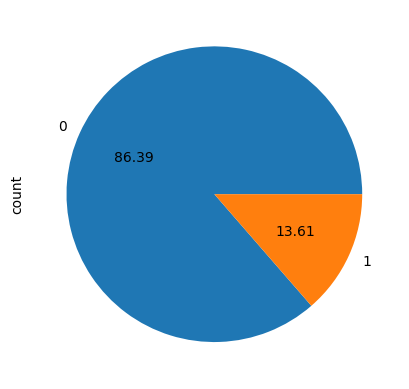

In [18]:
df['PitStop'].value_counts().plot(kind='pie',autopct='%.2f')

LapNumber

In [19]:
df['LapNumber'].nunique()

78

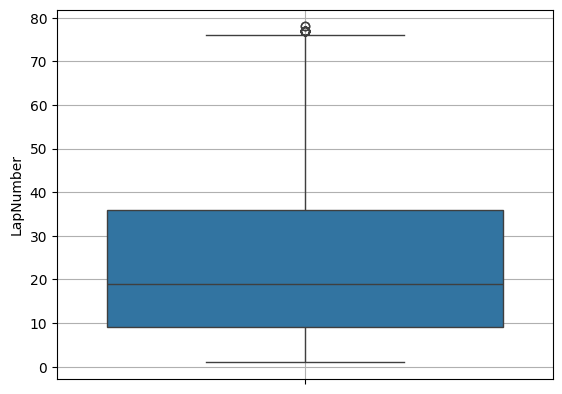

In [20]:
sns.boxplot(df['LapNumber'])
plt.grid(True)
plt.show()

In [21]:
df[df['LapNumber']>77].value_counts().sum()

np.int64(2)

Two outliers handle this in LapNumber

Stint

In [22]:
df['Stint'].nunique()

8

In [23]:
df['Stint'].unique()

array([2, 3, 1, 4, 5, 6, 8, 7])

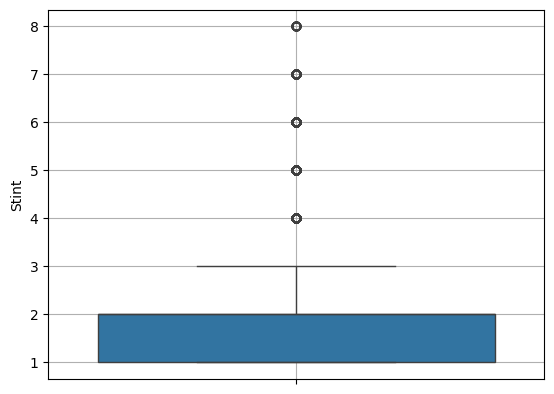

In [24]:
sns.boxplot(df['Stint'])
plt.grid(True)
plt.show()

In [25]:
df[df['Stint']>6].value_counts().sum()

np.int64(166)

In [26]:
df['Stint'].max()

8

Having outliers choose right model

TyreLife

In [27]:
df['TyreLife'].nunique()

78

In [28]:
df['TyreLife'].value_counts()

TyreLife
6.0     20663
4.0     20348
12.0    19945
3.0     18614
1.0     18440
        ...  
73.0       10
70.0        9
75.0        8
77.0        3
60.5        1
Name: count, Length: 78, dtype: int64

<Axes: ylabel='TyreLife'>

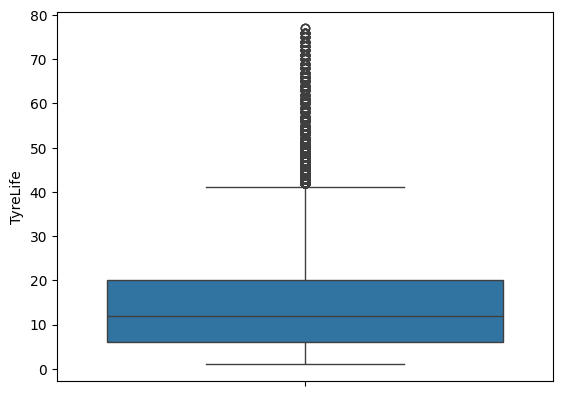

In [29]:
sns.boxplot(df['TyreLife'])

<Axes: xlabel='TyreLife', ylabel='Count'>

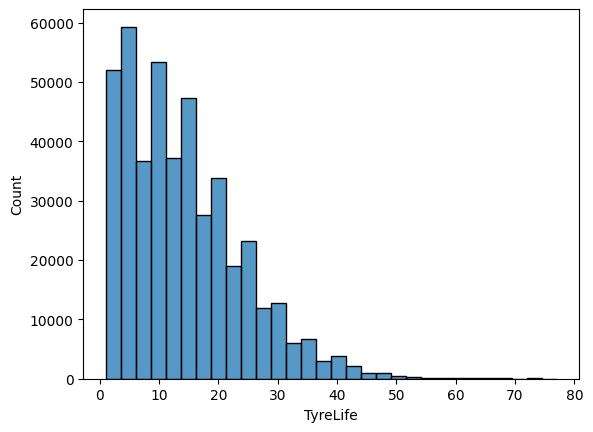

In [30]:
sns.histplot(df['TyreLife'],bins=30)

In [31]:
df[df['TyreLife']>65].value_counts().sum()

np.int64(240)

In [32]:
df['TyreLife'].max()

77.0

Handles carefully so much outliers

**Position**

In [33]:
df['Position'].nunique()

20

In [34]:
df['Position'].unique()

array([ 8,  4, 13,  7,  2,  5, 11,  1, 12, 10, 18, 15,  3, 20,  6, 17,  9,
       14, 16, 19])

In [35]:
df['Position'].value_counts()

Position
4     25267
11    25031
12    24937
13    24850
6     24845
8     24777
10    24700
7     24690
9     24416
5     24398
3     24285
15    23905
1     23841
14    23824
16    21769
2     21427
17    19886
18    15869
19    10615
20     5808
Name: count, dtype: int64

<Axes: ylabel='Position'>

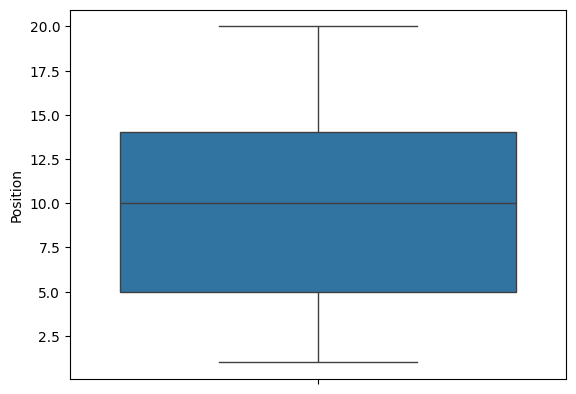

In [36]:
sns.boxplot(df['Position'])

No Outliers in Position

**Laptime**

In [37]:
df['LapTime (s)'].value_counts

<bound method IndexOpsMixin.value_counts of 0          78.491
1          75.095
2          70.945
3          94.361
4         107.878
           ...   
439135     92.638
439136     85.890
439137     91.644
439138     89.947
439139     91.691
Name: LapTime (s), Length: 439140, dtype: float64>

<Axes: ylabel='LapTime (s)'>

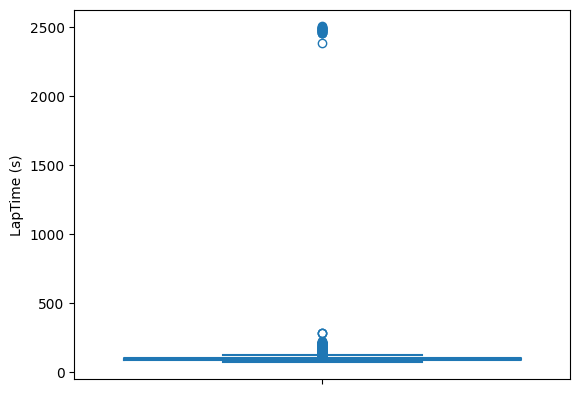

In [38]:
sns.boxplot(df['LapTime (s)'],fill=False)

<Axes: xlabel='LapTime (s)', ylabel='Count'>

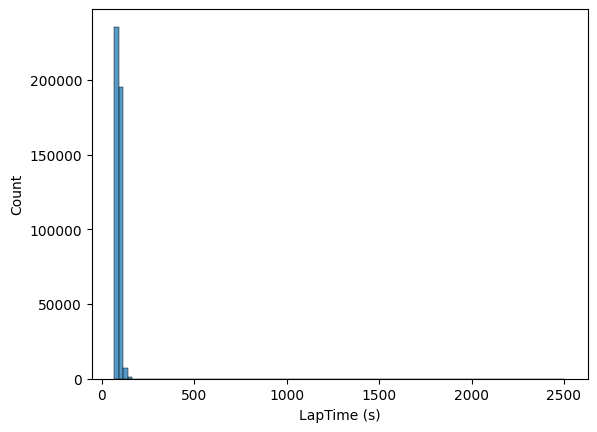

In [39]:
sns.histplot(df['LapTime (s)'],bins=100)

In [40]:
df[df['LapTime (s)']>200].value_counts().sum()

np.int64(37)

In LapTime take outliers because it takes long time to complete don't remove aggressively

**LapTime_Delta**

In [41]:
df['LapTime_Delta'].unique()

array([ -7.564, -32.617,  -7.54 , ...,  -9.024, -19.384, -69.695])

In [42]:
df['LapTime_Delta'].sort_values().head(10)

317668   -2403.895
310479   -2403.895
93159    -2403.067
41303    -2402.985
319433   -2402.692
107045   -2402.692
381086   -2402.690
83328    -2402.690
252382   -2402.690
234923   -2402.690
Name: LapTime_Delta, dtype: float64

<Axes: xlabel='LapTime_Delta', ylabel='Count'>

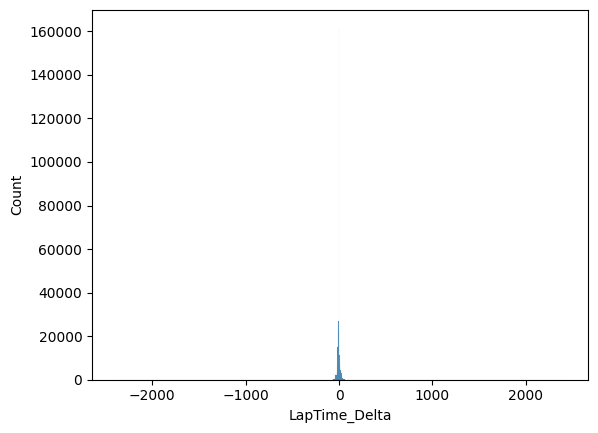

In [43]:
sns.histplot(df['LapTime_Delta'],bins=2000)

In [44]:
df[df['LapTime_Delta']>100].value_counts().sum()

np.int64(19)

In [45]:
df[df['LapTime_Delta']< -100].value_counts().sum()

np.int64(201)

<Axes: ylabel='LapTime_Delta'>

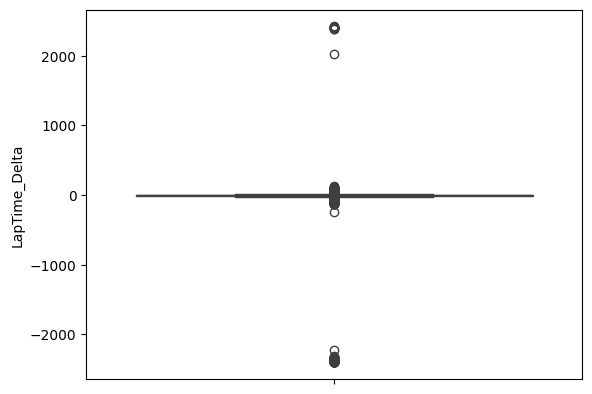

In [46]:
sns.boxplot(df['LapTime_Delta'])

Discuss these types of data behaviours

**  Cumulative_Degradation**

In [47]:
df['Cumulative_Degradation'].unique()

array([  21.019, -223.207, -100.529, ...,  -64.869, -191.313,  -17.202])

<Axes: ylabel='Cumulative_Degradation'>

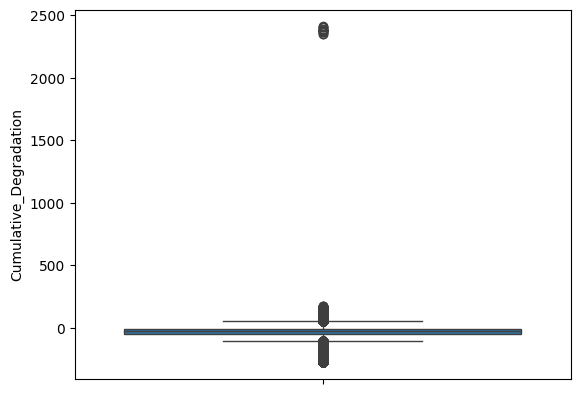

In [48]:
sns.boxplot(df['Cumulative_Degradation'])

<Axes: xlabel='Cumulative_Degradation', ylabel='Count'>

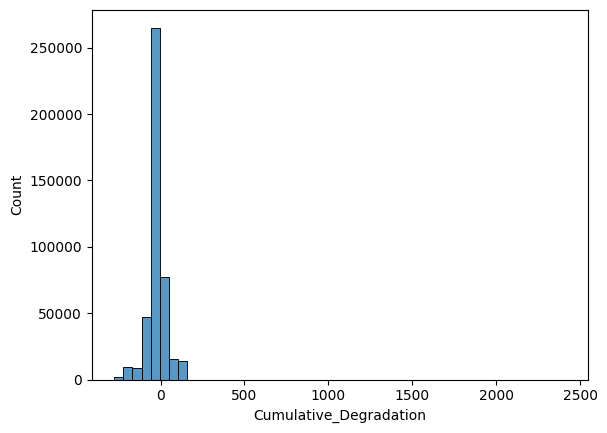

In [49]:
sns.histplot(df['Cumulative_Degradation'],bins=50)

<Axes: ylabel='RaceProgress'>

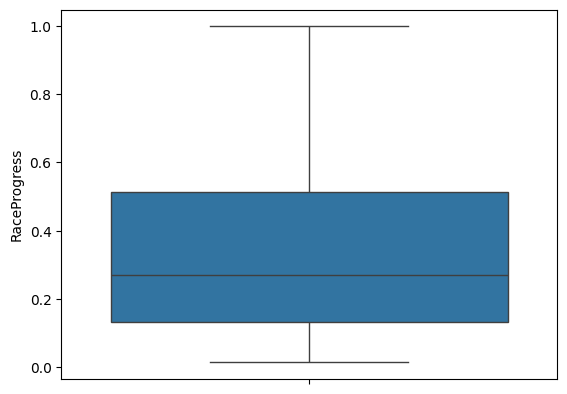

In [50]:
sns.boxplot(df['RaceProgress'])

Not outliers

<Axes: ylabel='Position_Change'>

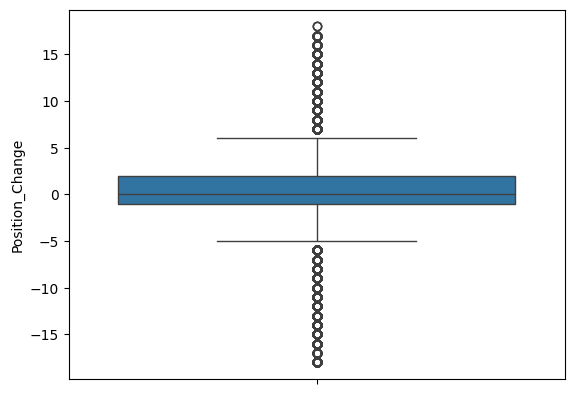

In [51]:
sns.boxplot(df["Position_Change"])

<Axes: xlabel='Position_Change', ylabel='Count'>

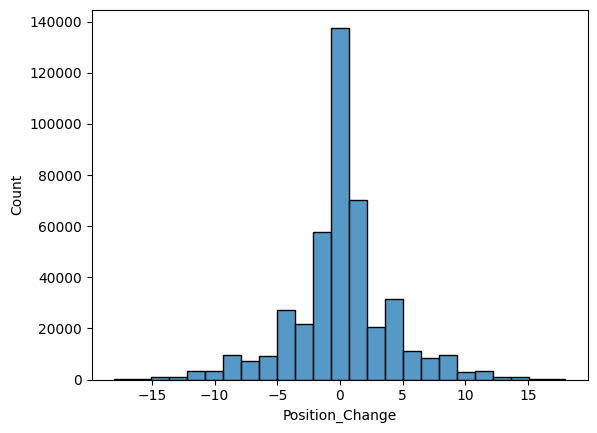

In [52]:
sns.histplot(df['Position_Change'],bins=25)

In [53]:
df['Position_Change'].unique()

array([  5.,  -3.,   3.,   0.,  -9.,   4.,   6.,  -1.,  -2.,   2.,   7.,
        -4.,   1.,  -8.,   8.,  -5.,   9.,  11.,  14.,  -6., -10., -11.,
        -7.,  10.,  13., -16., -12., -14., -13., -15.,  15.,  12.,  17.,
       -18.,  16., -17.,  18.])

<Axes: ylabel='count'>

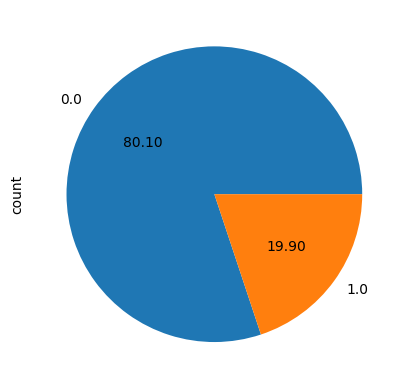

In [54]:
df['PitNextLap'].value_counts().plot(kind='pie',autopct="%.2f")

In [55]:
driver_id=df.iloc[:,0]

In [56]:
driver_id

0              0
1              1
2              2
3              3
4              4
           ...  
439135    439135
439136    439136
439137    439137
439138    439138
439139    439139
Name: id, Length: 439140, dtype: int64

In [57]:
df.drop(columns=['id'],inplace=True)

In [58]:
df.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


In [59]:
test_df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")

In [60]:
test_df.tail(3)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
188162,627302,D112,MEDIUM,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0
188163,627303,D349,MEDIUM,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0
188164,627304,D010,MEDIUM,Dutch Grand Prix,2022,0,14,1,14.0,2,76.831,-7.828,-54.204,0.194444,5.0


Bi-Variate Analysis

<Axes: xlabel='PitNextLap', ylabel='LapNumber'>

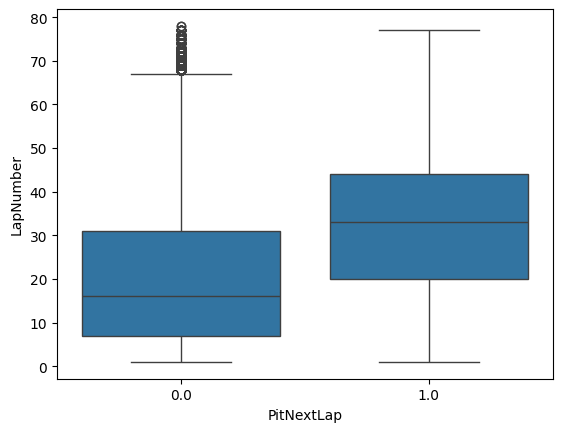

In [61]:
sns.boxplot(x='PitNextLap',y='LapNumber',data=df)

<Axes: xlabel='Compound', ylabel='count'>

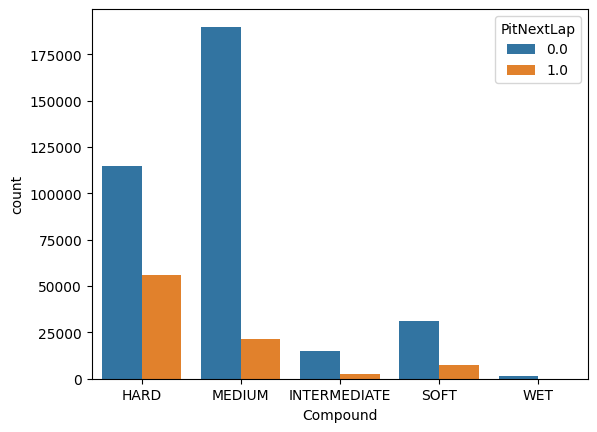

In [62]:
sns.countplot(x='Compound',hue='PitNextLap',data=df)

<Axes: xlabel='Stint', ylabel='count'>

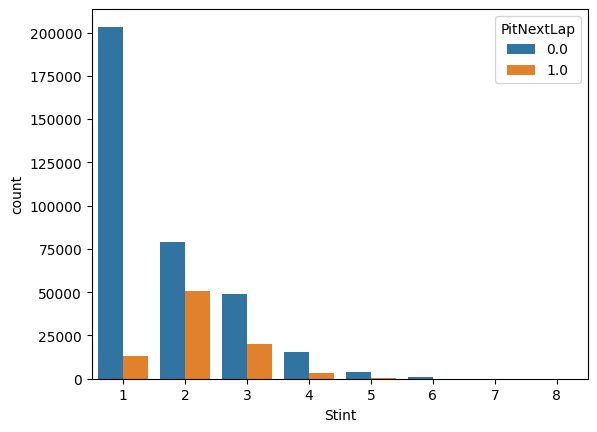

In [63]:
sns.countplot(x='Stint',hue='PitNextLap',data=df)

Import all related files

In [64]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    FunctionTransformer
)

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    roc_auc_score,
    RocCurveDisplay,
    classification_report
)

from xgboost import XGBClassifier


In [65]:
driver_freq = df['Driver'].value_counts()
df['Driver_Freq'] = df['Driver'].map(driver_freq)


In [66]:
driver_freq.sample(5)

Driver
D146     834
D331     139
LOP     1440
SCH     1413
D501      10
Name: count, dtype: int64

In [67]:
X = df.drop(columns=['PitNextLap','Driver'])
y = df['PitNextLap']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
ohe_cols = [
    'Compound',
    'Race'
]

In [70]:
numerical_cols = [
    'Year',
    'PitStop',
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Position_Change',
    'Driver_Freq'
]


In [71]:
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

In [72]:
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [73]:
trf1 = ColumnTransformer([
    ('num', numerical_pipe, numerical_cols),
    ('cat', categorical_pipe, ohe_cols)
])

In [74]:
from sklearn.feature_selection import SelectKBest, chi2

In [75]:
trf2 = SelectKBest(
    score_func=chi2,
    k='all'
)

In [76]:
trf3 = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8
)


In [77]:
pipe = Pipeline([
    ('trf1', trf1),
    ('trf2',trf2),
    ('trf3', trf3)
])

In [78]:
params = {
    'trf3__n_estimators': [100, 200],
    'trf3__max_depth': [4, 6, 8],
    'trf3__learning_rate': [0.01, 0.05, 0.1],
    'trf3__subsample': [0.8, 1]
}

In [79]:
grid = GridSearchCV(
    pipe,
    param_grid=params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [80]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('trf1',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['Year',
                                                                          'PitStop',
                                                                          'LapNumber',
                                                                          'Stint',
                                                                          'TyreLife',
                                                                          'Position',
                                                                          'LapTime '
                                                                          '(s)',
                                                                          'LapTime_Delta',
                                                                          'Cumulative_Degradation',
                                                                          'RaceProgress',
                                                                          'Position_Change',
                                                                          'Driver_Freq']),
                                                                        ('cat...
                                                      max_delta_step=None,
                                                      max_depth=6,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=200,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'trf3__learning_rate': [0.01, 0.05, 0.1],
                         'trf3__max_depth': [4, 6, 8],
                         'trf3__n_estimators': [100, 200],
                         'trf3__subsample': [0.8, 1]},
             scoring='roc_auc')

In [81]:
print(grid.best_params_)
print(grid.best_score_)

{'trf3__learning_rate': 0.1, 'trf3__max_depth': 8, 'trf3__n_estimators': 200, 'trf3__subsample': 0.8}
0.9476796145903096


In [82]:
y_prob = grid.predict_proba(X_test)[:,1]
y_pred = grid.predict(X_test)

In [83]:
roc_auc = roc_auc_score(y_test, y_prob)
print("\nTest ROC-AUC Score:")
print(roc_auc)


Test ROC-AUC Score:
0.9485741403311461


In [84]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.94     70352
         1.0       0.75      0.73      0.74     17476

    accuracy                           0.90     87828
   macro avg       0.84      0.83      0.84     87828
weighted avg       0.90      0.90      0.90     87828



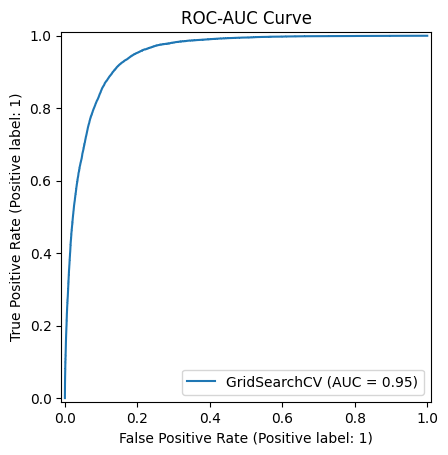

In [85]:
RocCurveDisplay.from_estimator(
    grid,
    X_test,
    y_test
)
plt.title("ROC-AUC Curve")
plt.show()

In [86]:
cv_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)
print("\nCross Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:")
print(cv_scores.mean())


Cross Validation ROC-AUC Scores:
[0.94254889 0.94302237 0.9432299  0.94167833 0.94197748]

Mean ROC-AUC:
0.9424913932823872


In [87]:
test_df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")

In [88]:
test_df.sample(5)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
12453,451593,D044,MEDIUM,Dutch Grand Prix,2025,0,5,1,5.0,20,77.026,-5.405,60.925,0.069444,-12.0
61557,500697,ALG,MEDIUM,São Paulo Grand Prix,2023,0,24,4,13.0,12,75.717,-0.078,-17.816,0.338028,0.0
35328,474468,FRE,HARD,Qatar Grand Prix,2025,0,53,3,22.0,9,88.865,3.970,-50.939,0.679487,0.0
41537,480677,D209,HARD,Mexico City Grand Prix,2024,1,9,2,2.0,20,83.675,-17.790,-29.408,0.118421,-6.0
140941,580081,D283,HARD,Miami Grand Prix,2023,0,38,1,35.0,7,92.766,0.103,-12.969,0.666667,0.0


In [89]:
test_ids = test_df['id']

In [90]:
driver_freq = df['Driver'].value_counts()
test_df['Driver_Freq'] = test_df['Driver'].map(driver_freq)

In [91]:
X_test_final = test_df.drop(columns=['Driver'])

In [92]:
final_predictions = grid.predict_proba(X_test_final)[:,1]

In [93]:
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': final_predictions
})

In [94]:
submission.sample(5)

,id,PitNextLap
16089,455229,0.471050
54997,494137,0.503659
166496,605636,0.024289
170049,609189,0.002565
123554,562694,0.000715


In [95]:
print(len(test_ids))
print(len(submission))

188165
188165


In [96]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [97]:
import os
os.listdir('/kaggle/working')

['submission.csv', '__notebook__.ipynb']